# EcoText - Sustainability Text Analyzer

This notebook builds a reproducible NLP workflow for classifying sustainability-related claims as `greenwashing` or `not_greenwashing`.

The supervised training data is `emerald_data.csv`. The sustainability report TXT file is treated as unlabeled raw text only: it is used for chunking, inference demos, sentiment scoring, suspicious phrase highlighting, and manual-review exports.

## 1. Setup and Reproducibility

In [12]:
import json
import math
import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path("emerald_data.csv")
REPORT_PATH = Path("201820Sustainability20English_pdf_extracted.txt")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

LABEL_MAPPING = {"not_greenwashing": 0, "greenwashing": 1}
INVERSE_LABEL_MAPPING = {v: k for k, v in LABEL_MAPPING.items()}

SUSPICIOUS_PHRASES = [
    "sustainable solutions", "positive impact", "meaningful change",
    "better tomorrow", "eco-friendly", "green", "carbon neutral",
    "net zero", "environmentally friendly", "committed to sustainability",
    "reducing our footprint", "responsible choice", "sustainably",
    "climate positive", "nature positive", "planet friendly",
    "future generations"
]

In [13]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def fix_encoding_artifacts(text):
    replacements = {
        "â€™": "'", "â€œ": '"', "â€\x9d": '"', "â€": '"',
        "â€“": "-", "â€”": "-", "Â": "", "\ufeff": ""
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return text


def detect_suspicious_phrases(text, phrases=SUSPICIOUS_PHRASES):
    found = []
    lower = str(text).lower()
    for phrase in phrases:
        pattern = r"(?<!\w)" + re.escape(phrase.lower()) + r"(?!\w)"
        if re.search(pattern, lower):
            found.append(phrase)
    return found


def highlight_suspicious_phrases(text, phrases=SUSPICIOUS_PHRASES):
    highlighted = str(text)
    for phrase in sorted(phrases, key=len, reverse=True):
        pattern = re.compile(r"(?i)(?<!\w)(" + re.escape(phrase) + r")(?!\w)")
        highlighted = pattern.sub(r"<mark>\1</mark>", highlighted)
    return highlighted


def get_positive_scores(model, texts):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(texts)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(texts)
        return 1 / (1 + np.exp(-scores))
    return None


def evaluate_model(name, model, texts, y_true, split_name):
    y_pred = model.predict(texts)
    pos_scores = get_positive_scores(model, texts)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    row = {
        "model": name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_greenwashing": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_greenwashing": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_greenwashing": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
        "roc_auc": np.nan,
        "average_precision_pr_auc": np.nan,
        "brier_score": np.nan,
    }
    if pos_scores is not None and len(np.unique(y_true)) == 2:
        row["roc_auc"] = roc_auc_score(y_true, pos_scores)
        row["average_precision_pr_auc"] = average_precision_score(y_true, pos_scores)
        row["brier_score"] = brier_score_loss(y_true, pos_scores)
    return row


def show_errors(model, frame, n=5):
    temp = frame[["claim_clean", "gold_label", "label"]].copy()
    temp["pred"] = model.predict(temp["claim_clean"])
    temp["greenwashing_probability"] = get_positive_scores(model, temp["claim_clean"])
    fp = temp[(temp["label"] == 0) & (temp["pred"] == 1)].sort_values("greenwashing_probability", ascending=False)
    fn = temp[(temp["label"] == 1) & (temp["pred"] == 0)].sort_values("greenwashing_probability", ascending=True)
    print("False positives: predicted greenwashing but actually not_greenwashing")
    display(fp.head(n))
    print("False negatives: predicted not_greenwashing but actually greenwashing")
    display(fn.head(n))

## 2. Data Loading and Inspection

In [14]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print("Columns:", df.columns.tolist())
display(df.isna().sum().to_frame("missing_values"))
print("Duplicate claims:", df["claim"].duplicated().sum())
display(df["gold_label"].value_counts().to_frame("count"))

df["claim_clean"] = df["claim"].map(clean_text)
df["label"] = df["gold_label"].map(LABEL_MAPPING).astype(int)

print("Samples from each class:")
display(df.groupby("gold_label", group_keys=False).sample(n=3, random_state=SEED)[["claim", "gold_label", "justification"]])

# Heuristic check only: these are not automatic errors, just rows worth reading.
specific_words = r"\b(approximately|\d|percent|%|tonnes?|million|billion|reduced|increased|measured|certified)\b"
vague_words = r"\b(green|eco-friendly|better tomorrow|positive impact|meaningful change|sustainable solutions|committed)\b"
mismatch_candidates = df[
    ((df["gold_label"].eq("greenwashing")) & df["claim_clean"].str.contains(specific_words, case=False, regex=True, na=False)) |
    ((df["gold_label"].eq("not_greenwashing")) & df["claim_clean"].str.contains(vague_words, case=False, regex=True, na=False))
]
print("Heuristic label/claim review candidates:", len(mismatch_candidates))
display(mismatch_candidates[["claim", "gold_label", "justification"]].head(15))

Shape: (620, 5)


,unique_id,claim,gold_label,company,justification
0,0,EVgo and Amazon partner to enable voice-initia...,not_greenwashing,EVgo / Amazon,This is a factual statement describing the new...
1,1,"Amazon's Alexa now helps EV drivers find, navi...",not_greenwashing,Amazon,This is a factual description of the new featu...
2,2,Delta reduced its onboard single-use plastic c...,not_greenwashing,Delta,"This is a specific, quantifiable achievement d..."
3,3,"Delta announces a ""zero-waste flight"" as part ...",not_greenwashing,Delta,"The ""zero-waste flight"" was a specific, one-of..."
4,4,Delta is using more fuel-efficient A321neo air...,not_greenwashing,Delta,"This is a specific, verifiable improvement in ..."


Columns: ['unique_id', 'claim', 'gold_label', 'company', 'justification']


,missing_values
unique_id,0
claim,0
gold_label,0
company,0
justification,0


Duplicate claims: 0


,count
gold_label,
not_greenwashing,395
greenwashing,225


Samples from each class:


,claim,gold_label,justification
30,"Amazon introduces a new ""Plastic-Free Shipping...",greenwashing,"Offering a specific, verifiable plastic-free a..."
492,Starbucks has eliminated single-use cups for 1...,greenwashing,The article clearly states that the eliminatio...
319,Interface is a sustainable company because it ...,greenwashing,Presenting compliance with environmental regul...
394,HSBC UK is making it easier for small business...,not_greenwashing,"The article details the Green SME Fund, cashba..."
396,HSBC UK is addressing climate change by provid...,not_greenwashing,"While HSBC UK has a specific green fund, this ..."
353,"Shell Energy promotes its ""cleaner energy solu...",not_greenwashing,"The term ""cleaner energy solutions"" is vague a..."


Heuristic label/claim review candidates: 61


,claim,gold_label,justification
9,Delta is committed to achieving net zero emiss...,not_greenwashing,"While a positive goal, setting a net-zero targ..."
43,Lufthansa Group proudly commits to replacing 5...,greenwashing,"While a commitment, the 5% SAF target is the *..."
52,"Amazon's $150 million investment ""solves inequ...",greenwashing,"While the investment addresses inequities, cla..."
63,Amazon: Committed to strengthening communities...,not_greenwashing,This claim overgeneralizes Amazon's commitment...
74,Amazon's Housing Equity Fund has committed ove...,not_greenwashing,"This is a specific, quantifiable, and verifiab..."
75,"Amazon states it is ""committed to doing our pa...",not_greenwashing,"The phrase ""doing our part to improve our regi..."
97,Amazon is committed to providing free cloud co...,not_greenwashing,"This is a clear, measurable, and publicly stat..."
128,Sound Transit CEO Peter Rogoff states Amazon's...,greenwashing,This directly quotes a key stakeholder in the ...
178,Allbirds' M0.0NSHOT packaging is made from sug...,not_greenwashing,"This is a specific, verifiable detail about su..."
185,Shell committed in 2020 to achieve net zero in...,not_greenwashing,"This is a specific, verifiable commitment rela..."


## 3. Stratified Train/Validation/Test Split

The report TXT is not used in supervised training, which prevents leakage from unlabeled corporate report text into the classifier.

In [15]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(name, frame.shape)
    display(frame["gold_label"].value_counts(normalize=True).rename("proportion").to_frame())

train (434, 7)


,proportion
gold_label,
not_greenwashing,0.635945
greenwashing,0.364055


validation (93, 7)


,proportion
gold_label,
not_greenwashing,0.634409
greenwashing,0.365591


test (93, 7)


,proportion
gold_label,
not_greenwashing,0.645161
greenwashing,0.354839


## 4. Classic ML Baselines

These models use conservative preprocessing: whitespace cleanup plus TF-IDF lowercasing inside the vectorizer.

In [16]:
base_tfidf = {
    "tfidf__ngram_range": (1, 2),
    "tfidf__min_df": 2,
    "tfidf__max_df": 0.95,
    "tfidf__sublinear_tf": True,
}

models = {
    "TF-IDF + Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]).set_params(**base_tfidf),
    "TF-IDF + Calibrated Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True)),
        ("clf", CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=SEED), cv=3)),
    ]).set_params(**base_tfidf),
    "TF-IDF + Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True)),
        ("clf", MultinomialNB(alpha=0.5)),
    ]).set_params(**base_tfidf),
    "TF-IDF + Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, max_features=5000)),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced", random_state=SEED, n_jobs=-1)),
    ]),
}

try:
    from xgboost import XGBClassifier
    models["TF-IDF + XGBoost"] = Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, max_features=6000)),
        ("clf", XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=SEED)),
    ])
except Exception as exc:
    print("Skipping XGBoost:", exc)

rows = []
fitted_models = {}
for name, model in models.items():
    print(f"Training {name}")
    model.fit(train_df["claim_clean"], train_df["label"])
    fitted_models[name] = model
    rows.append(evaluate_model(name, model, val_df["claim_clean"], val_df["label"], "validation"))
    rows.append(evaluate_model(name, model, test_df["claim_clean"], test_df["label"], "test"))

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values(["split", "f1_greenwashing", "macro_f1"], ascending=[True, False, False]))
metrics_df.to_csv(ARTIFACT_DIR / "model_comparison_metrics.csv", index=False)

Training TF-IDF + Logistic Regression
Training TF-IDF + Calibrated Linear SVM
Training TF-IDF + Multinomial Naive Bayes
Training TF-IDF + Random Forest
Training TF-IDF + XGBoost


,model,split,accuracy,precision_greenwashing,recall_greenwashing,f1_greenwashing,macro_f1,weighted_f1,tn,fp,fn,tp,roc_auc,average_precision_pr_auc,brier_score
1,TF-IDF + Logistic Regression,test,0.806452,0.702703,0.787879,0.742857,0.793842,0.808645,49,11,7,26,0.859091,0.797460,0.176235
7,TF-IDF + Random Forest,test,0.806452,0.702703,0.787879,0.742857,0.793842,0.808645,49,11,7,26,0.878283,0.802266,0.164903
5,TF-IDF + Multinomial Naive Bayes,test,0.817204,0.807692,0.636364,0.711864,0.789003,0.811398,55,5,12,21,0.862121,0.811965,0.139820
3,TF-IDF + Calibrated Linear SVM,test,0.806452,0.777778,0.636364,0.700000,0.778571,0.801382,54,6,12,21,0.870202,0.806352,0.145117
9,TF-IDF + XGBoost,test,0.795699,0.733333,0.666667,0.698413,0.771971,0.793326,52,8,11,22,0.836364,0.726126,0.159461
0,TF-IDF + Logistic Regression,validation,0.709677,0.606061,0.588235,0.597015,0.685062,0.708731,46,13,14,20,0.781157,0.723919,0.198909
6,TF-IDF + Random Forest,validation,0.709677,0.612903,0.558824,0.584615,0.680737,0.706577,47,12,15,19,0.756730,0.718822,0.194617
8,TF-IDF + XGBoost,validation,0.709677,0.620690,0.529412,0.571429,0.675958,0.704058,48,11,16,18,0.728315,0.716120,0.191838
2,TF-IDF + Calibrated Linear SVM,validation,0.731183,0.695652,0.470588,0.561404,0.683803,0.716705,52,7,18,16,0.781655,0.715491,0.179377
4,TF-IDF + Multinomial Naive Bayes,validation,0.709677,0.629630,0.500000,0.557377,0.670689,0.701149,49,10,17,17,0.749252,0.683477,0.189847


## 5. Metrics, Confidence, Calibration, and Error Analysis

Best validation model: TF-IDF + Logistic Regression


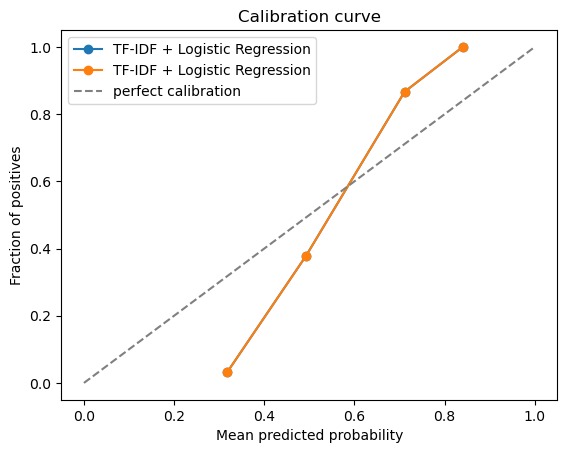

Classification report for deployable model:
                  precision    recall  f1-score   support

not_greenwashing       0.88      0.82      0.84        60
    greenwashing       0.70      0.79      0.74        33

        accuracy                           0.81        93
       macro avg       0.79      0.80      0.79        93
    weighted avg       0.81      0.81      0.81        93

False positives: predicted greenwashing but actually not_greenwashing


,claim_clean,gold_label,label,pred,greenwashing_probability
21,"Amazon promotes its new electric vans as ""eco-...",not_greenwashing,0,1,0.748436
0,Etihad Airways is working towards achieving ne...,not_greenwashing,0,1,0.612965
84,Nestlé UK & Ireland and Cargill have partnered...,not_greenwashing,0,1,0.599138
9,Amazon is helping diverse founders get the cap...,not_greenwashing,0,1,0.570778
77,Shell's annual report highlights $2.4 billion ...,not_greenwashing,0,1,0.561859


False negatives: predicted not_greenwashing but actually greenwashing


,claim_clean,gold_label,label,pred,greenwashing_probability
76,Amazon's AWS re/Start program is making skills...,greenwashing,1,0,0.359940
48,Nestlé is on track to achieve net zero greenho...,greenwashing,1,0,0.400258
71,"Amazon is building ""sustainable communities"" b...",greenwashing,1,0,0.420422
12,Amazon guarantees a 25% reduction in workplace...,greenwashing,1,0,0.425456
65,"Shell is on track to meet its climate targets,...",greenwashing,1,0,0.428660


In [17]:
val_metrics = metrics_df[metrics_df["split"].eq("validation")].sort_values(
    ["f1_greenwashing", "macro_f1", "average_precision_pr_auc"],
    ascending=False,
    na_position="last",
)
best_validation_name = val_metrics.iloc[0]["model"]
best_validation_model = fitted_models[best_validation_name]
print("Best validation model:", best_validation_name)

deployable_name = "TF-IDF + Logistic Regression"
deployable_model = fitted_models[deployable_name]

for name in [deployable_name, best_validation_name]:
    model = fitted_models[name]
    y_score = get_positive_scores(model, test_df["claim_clean"])
    if y_score is None:
        continue
    prob_true, prob_pred = calibration_curve(test_df["label"], y_score, n_bins=5)
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve")
plt.legend()
plt.show()

print("Classification report for deployable model:")
print(classification_report(test_df["label"], deployable_model.predict(test_df["claim_clean"]), target_names=["not_greenwashing", "greenwashing"]))
show_errors(deployable_model, test_df, n=5)

## 6. Sentiment + Classification Combo and Suspicious Phrase Highlighting

In [18]:
POSITIVE_WORDS = {
    "accelerate", "achieve", "benefit", "better", "clean", "efficient",
    "good", "healthy", "improve", "innovation", "meaningful", "positive",
    "progress", "responsible", "safe", "sustainable", "value"
}
NEGATIVE_WORDS = {
    "bad", "challenge", "concern", "damage", "emission", "failure", "harm",
    "impact", "pollution", "problem", "risk", "scarcity", "waste"
}

def simple_sentiment(text):
    tokens = re.findall(r"[a-z]+", str(text).lower())
    if not tokens:
        return "neutral", 0.0
    pos = sum(token in POSITIVE_WORDS for token in tokens)
    neg = sum(token in NEGATIVE_WORDS for token in tokens)
    score = (pos - neg) / math.sqrt(len(tokens))
    if score >= 0.15:
        label = "positive"
    elif score <= -0.15:
        label = "negative"
    else:
        label = "neutral"
    return label, float(score)

try:
    from nltk.sentiment import SentimentIntensityAnalyzer
    vader = SentimentIntensityAnalyzer()

    def sentiment_analyze(text):
        compound = vader.polarity_scores(text)["compound"]
        if compound >= 0.05:
            return "positive", compound
        if compound <= -0.05:
            return "negative", compound
        return "neutral", compound
except Exception as exc:
    print("VADER unavailable; using a small transparent fallback lexicon.")
    print("To use VADER: pip install nltk, then run nltk.download('vader_lexicon')")
    sentiment_analyze = simple_sentiment

def analyze_claim(text, model=deployable_model):
    cleaned = clean_text(text)
    proba_green = model.predict_proba([cleaned])[0, 1]
    pred = int(proba_green >= 0.5)
    sent_label, sent_score = sentiment_analyze(cleaned)
    return {
        "text": cleaned,
        "predicted_label": INVERSE_LABEL_MAPPING[pred],
        "greenwashing_confidence": float(proba_green if pred == 1 else 1 - proba_green),
        "greenwashing_probability": float(proba_green),
        "sentiment_label": sent_label,
        "sentiment_score": sent_score,
        "suspicious_phrases": detect_suspicious_phrases(cleaned),
        "highlighted_html": highlight_suspicious_phrases(cleaned),
    }

demo = "We are committed to sustainability and delivering sustainable solutions for a better tomorrow."
analyze_claim(demo)

VADER unavailable; using a small transparent fallback lexicon.
To use VADER: pip install nltk, then run nltk.download('vader_lexicon')


{'text': 'We are committed to sustainability and delivering sustainable solutions for a better tomorrow.',
 'predicted_label': 'greenwashing',
 'greenwashing_confidence': 0.5664918933623485,
 'greenwashing_probability': 0.5664918933623485,
 'sentiment_label': 'positive',
 'sentiment_score': 0.5547001962252291,
 'suspicious_phrases': ['sustainable solutions',
  'better tomorrow',
  'committed to sustainability'],
 'highlighted_html': 'We are <mark>committed to sustainability</mark> and delivering <mark>sustainable solutions</mark> for a <mark>better tomorrow</mark>.'}

## 7. TXT Sustainability Report Processing

In [19]:
def chunk_report(path):
    raw = path.read_text(encoding="utf-8", errors="replace")
    raw = fix_encoding_artifacts(raw)
    lines = [clean_text(line) for line in raw.splitlines()]
    drop_patterns = [
        r"^ecolab sustainability report 2018\s+\d+$",
        r"^accelerating meaningful change contents$",
    ]
    kept = []
    for line in lines:
        if not line:
            kept.append("")
            continue
        if any(re.match(pattern, line, flags=re.I) for pattern in drop_patterns):
            continue
        kept.append(line)

    paragraphs = []
    current = []
    for line in kept:
        if not line:
            if current:
                paragraphs.append(" ".join(current))
                current = []
            continue
        current.append(line)
    if current:
        paragraphs.append(" ".join(current))

    chunks = []
    for paragraph in paragraphs:
        paragraph = clean_text(paragraph)
        if len(paragraph) < 40:
            continue
        sentences = re.split(r"(?<=[.!?])\s+(?=[A-Z0-9])", paragraph)
        buffer = []
        for sentence in sentences:
            sentence = clean_text(sentence)
            if not sentence:
                continue
            buffer.append(sentence)
            joined = " ".join(buffer)
            if len(joined) >= 180:
                chunks.append(joined)
                buffer = []
        if buffer:
            chunks.append(" ".join(buffer))
    return [chunk for chunk in chunks if len(chunk) >= 50]

chunks = chunk_report(REPORT_PATH)
print("Chunks:", len(chunks))
chunk_df = pd.DataFrame({"chunk_text": chunks})

proba = deployable_model.predict_proba(chunk_df["chunk_text"])[:, 1]
pred = (proba >= 0.5).astype(int)
sentiments = chunk_df["chunk_text"].map(sentiment_analyze)

chunk_df["predicted_label"] = [INVERSE_LABEL_MAPPING[int(label)] for label in pred]
chunk_df["confidence"] = np.where(pred == 1, proba, 1 - proba)
chunk_df["greenwashing_probability"] = proba
chunk_df["sentiment_label"] = [item[0] for item in sentiments]
chunk_df["sentiment_score"] = [item[1] for item in sentiments]
chunk_df["suspicious_phrases"] = chunk_df["chunk_text"].map(lambda text: "; ".join(detect_suspicious_phrases(text)))
chunk_df["highlighted_html"] = chunk_df["chunk_text"].map(highlight_suspicious_phrases)

top_suspicious_chunks = chunk_df.sort_values(
    ["greenwashing_probability", "suspicious_phrases"],
    ascending=[False, False],
).head(50)
display(top_suspicious_chunks)
top_suspicious_chunks.to_csv(ARTIFACT_DIR / "top_suspicious_chunks.csv", index=False)

Chunks: 229


,chunk_text,predicted_label,confidence,greenwashing_probability,sentiment_label,sentiment_score,suspicious_phrases,highlighted_html
67,Ecolab helps SAP minimize risks and avoid unex...,greenwashing,0.592305,0.592305,neutral,-0.149071,,Ecolab helps SAP minimize risks and avoid unex...
60,"As digital traffic grows, data centers are exp...",greenwashing,0.561979,0.561979,neutral,0.000000,,"As digital traffic grows, data centers are exp..."
214,Ecolab’s comprehensive 2018 Corporate Sustaina...,greenwashing,0.546584,0.546584,neutral,0.000000,,Ecolab’s comprehensive 2018 Corporate Sustaina...
21,We can’t turn the world around all by ourselve...,greenwashing,0.534681,0.534681,neutral,0.000000,,We can’t turn the world around all by ourselve...
221,EPA local factor of 1.5 lb CO2e/kwh. https://w...,greenwashing,0.533644,0.533644,neutral,0.000000,,EPA local factor of 1.5 lb CO2e/kwh. https://w...
7,Whether it’s saving water and energy or reduci...,greenwashing,0.533163,0.533163,negative,-0.179605,,Whether it’s saving water and energy or reduci...
185,ECOLAB SUSTAINABILITY REPORT 2018 35 2018 SAFE...,greenwashing,0.531937,0.531937,positive,0.166667,,ECOLAB SUSTAINABILITY REPORT 2018 35 2018 SAFE...
58,"The key element is the Stealth™ Fly Station, a...",greenwashing,0.528687,0.528687,neutral,0.000000,,"The key element is the Stealth™ Fly Station, a..."
82,We’re learning all the time.” For a small rest...,greenwashing,0.526441,0.526441,neutral,0.144338,,We’re learning all the time.” For a small rest...
107,Now is the time to get water-smart. 24 ECOLAB ...,greenwashing,0.522807,0.522807,neutral,0.000000,,Now is the time to get water-smart. 24 ECOLAB ...


## 8. Save Deployable Artifacts

In [20]:
final_train_df = pd.concat([train_df, val_df], ignore_index=True)
selected_model = clone(fitted_models[deployable_name])
selected_model.fit(final_train_df["claim_clean"], final_train_df["label"])

joblib.dump(selected_model, ARTIFACT_DIR / "ecotext_tfidf_logreg.joblib")
(ARTIFACT_DIR / "label_mapping.json").write_text(json.dumps(LABEL_MAPPING, indent=2), encoding="utf-8")
(ARTIFACT_DIR / "suspicious_phrases.json").write_text(json.dumps(SUSPICIOUS_PHRASES, indent=2), encoding="utf-8")

print("Saved:")
print(ARTIFACT_DIR / "ecotext_tfidf_logreg.joblib")
print(ARTIFACT_DIR / "label_mapping.json")
print(ARTIFACT_DIR / "suspicious_phrases.json")
print(ARTIFACT_DIR / "model_comparison_metrics.csv")
print(ARTIFACT_DIR / "top_suspicious_chunks.csv")

Saved:
artifacts\ecotext_tfidf_logreg.joblib
artifacts\label_mapping.json
artifacts\suspicious_phrases.json
artifacts\model_comparison_metrics.csv
artifacts\top_suspicious_chunks.csv
